<a href="https://colab.research.google.com/github/Yosh004/TelcoCustomerChurn/blob/main/TelcoCustomerChurnCW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#adding styles for the plots
sns.set_style('whitegrid')
try:
    df = pd.read_csv('/content/drive/MyDrive/TelcoCustomerChurn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: The CSV file was not found. Please check the file path.")

Dataset loaded successfully.


Task 1 - Exploratory Data Anaysis(EDA)

In [2]:
#Initial inspection of the Telco dataset
print("Initial inpsection of the dataSet")
print("\nFirst 5 rows of the TelcoDataSet:")
print(df.head())
print("\nData Structure and Types:")
df.info()
print(f"\nNumber of duplicated rows: {df.duplicated().sum()}")
print("\nStatistical Summary of Numerical Columns:")
print(df.describe())
df.drop('customerID', axis=1, inplace=True)
print("\n'customerID' column dropped.")#removing the customerID column as it is unique

Initial inpsection of the dataSet

First 5 rows of the TelcoDataSet:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               

In [3]:
#Data cleaning and handling missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')# Convert 'TotalCharges' to numeric
missing_values = df.isnull().sum()# Identify the missing values
print("\nMissing values per column (after TotalCharges fix):")
print(missing_values[missing_values > 0])
df.dropna(inplace=True)#remove missing values (Only small amount available)
print(f"\nRemaining rows after dropping Not a number values: {df.shape[0]}")


Missing values per column (after TotalCharges fix):
TotalCharges    11
dtype: int64

Remaining rows after dropping Not a number values: 7032



 Target Variable Analysis 

Churn Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage: 
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64%


/tmp/ipython-input-1373695277.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='pastel')


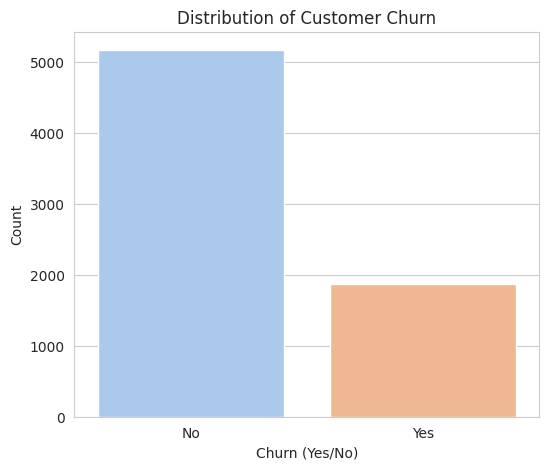

In [4]:
print("\n Target Variable Analysis ")
churn_counts = df['Churn'].value_counts()
churn_ratio = df['Churn'].value_counts(normalize=True) * 100
print("\nChurn Counts:")
print(churn_counts)
print(f"\nChurn Percentage: \n{churn_ratio.round(2)}%")
# Visualize the Churn distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=df, palette='pastel')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (Yes/No)')
plt.ylabel('Count')
plt.show()


 Categorical Feature Analysis vs. Churn 


/tmp/ipython-input-4171306762.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


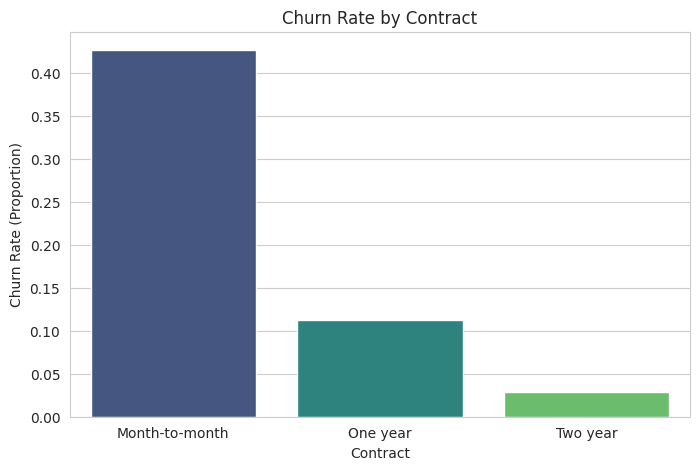

/tmp/ipython-input-4171306762.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


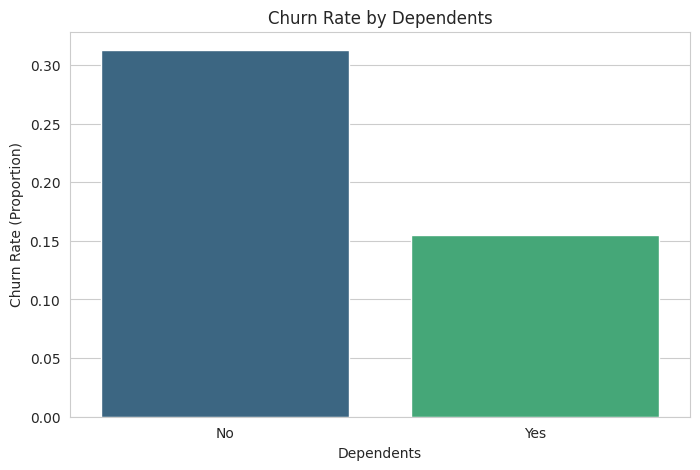

/tmp/ipython-input-4171306762.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


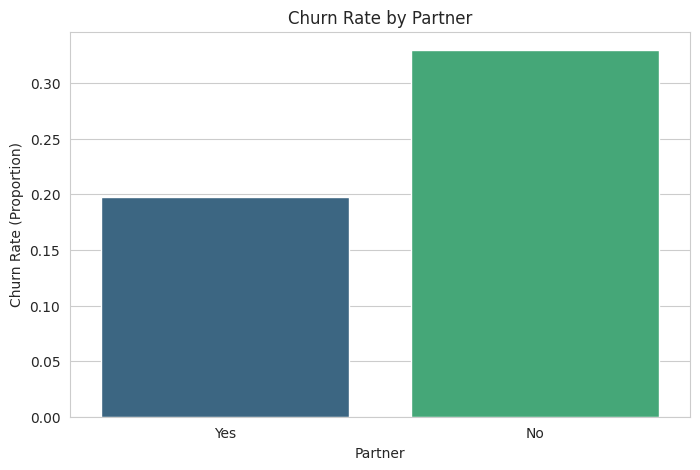

/tmp/ipython-input-4171306762.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


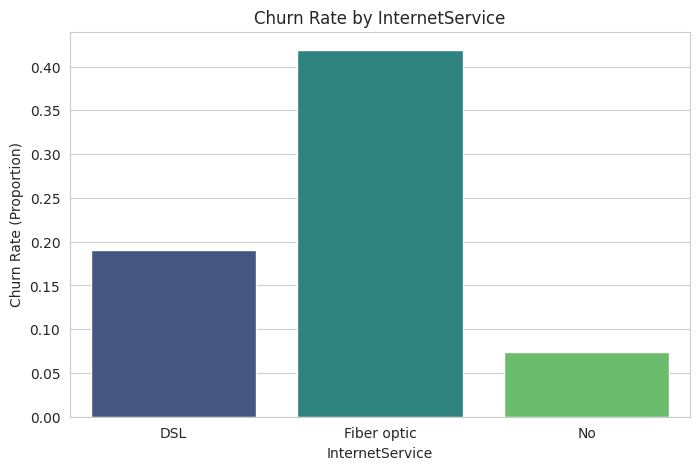

/tmp/ipython-input-4171306762.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-4171306762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


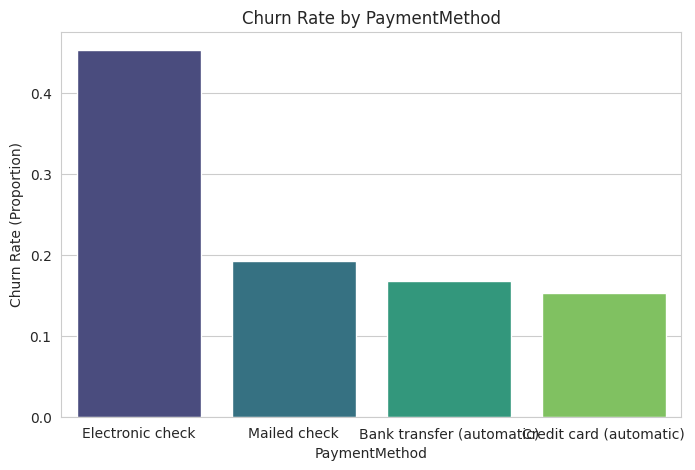


## Numerical Feature Analysis vs. Churn ##


/tmp/ipython-input-4171306762.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=column, data=df, palette='Set2')


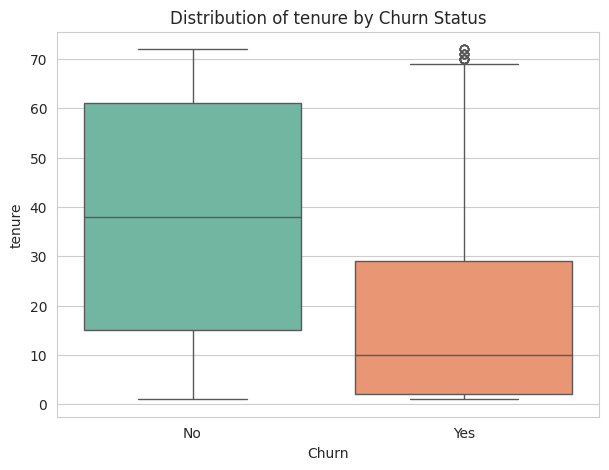

/tmp/ipython-input-4171306762.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=column, data=df, palette='Set2')


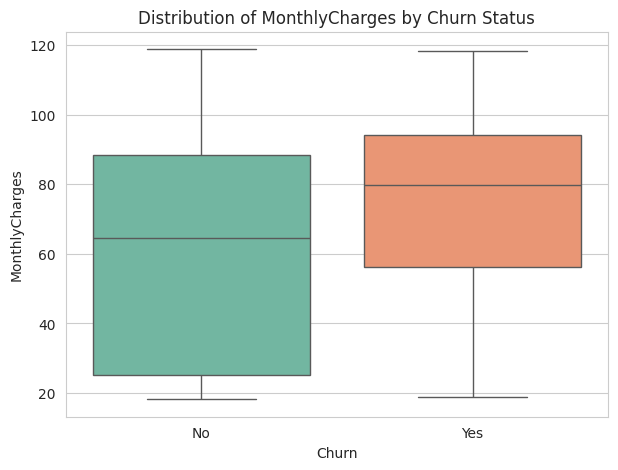


 Numerical Correlation Analysis 


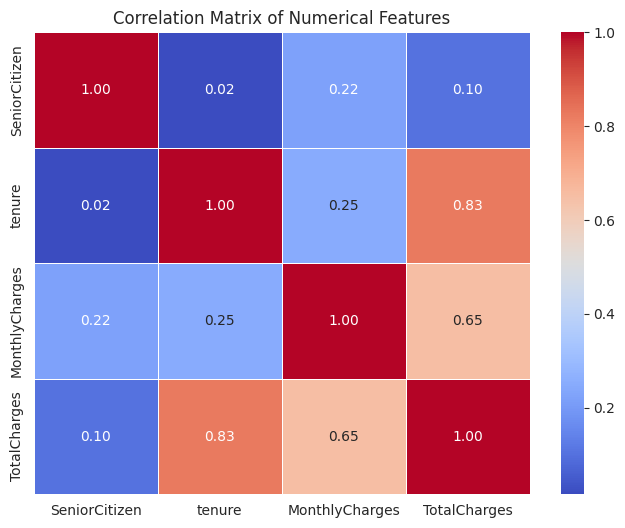

In [5]:
#Exploratory Data Analysis (Feature vs. Churn)

#Categorical Features Analysis
print("\n Categorical Feature Analysis vs. Churn ")
categoricalFeatures = ['Contract', 'Dependents', 'Partner', 'InternetService', 'PaymentMethod']
def plotCategoricalChurn(df, column):
    plt.figure(figsize=(8, 5))
    # Use a normalized bar plot to show the percentage of churn within each category
    sns.barplot(
        x=column,
        y='Churn',
        data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
        estimator=np.mean, # Calculates the mean of 'Churn' (which is the Churn rate)
        ci=None,
        palette='viridis'
    )
    plt.title(f'Churn Rate by {column}')
    plt.ylabel('Churn Rate (Proportion)')
    plt.show()

for feature in categoricalFeatures:
    plotCategoricalChurn(df, feature)

#Numerical Features Analysis(Box plot visualization)
print("\n## Numerical Feature Analysis vs. Churn ##")
numericalFeatures = ['tenure', 'MonthlyCharges']
def plotNumericalChurn(df, column):
    plt.figure(figsize=(7, 5))
    sns.boxplot(x='Churn', y=column, data=df, palette='Set2')
    plt.title(f'Distribution of {column} by Churn Status')
    plt.show()

for feature in numericalFeatures:
      plotNumericalChurn(df, feature)

#Numerical Correlation Analysis (Heat map)
print("\n Numerical Correlation Analysis ")
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix=numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(
correlation_matrix,
annot=True,
fmt=".2f",
cmap='coolwarm',
linewidths=0.5
)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


Task 2 - Data Cleaning, Preprocessing and classification using Neural Network and Decision Tree models

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score

#Load and clean data
try:
  df=pd.read_csv('CSVs/WA_Fn-UseC_-Telco-Customer-Churn.csv')
  print("Dataset loaded successfully.")
except FileNotFoundError:
  print("Error: The CSV file was not found. Please check the file path.")
  exit()
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.dropna(inplace=True)
print(f"Data cleaned. Remaining rows: {df.shape[0]}")

#Feature seperation and target
X=df.drop('Churn', axis=1)
y=df['Churn']
#turn yes/no into 0/1
le=LabelEncoder()
y=le.fit_transform(y)
#Find numerical columns and text columns
numericalFeatures=X.select_dtypes(include=['int64', 'float64']).columns
categoricalFeatures=X.select_dtypes(include=['object']).columns

#Scale numbers + one-hot encode
numericalTransformer=StandardScaler()
categoricalTransformer=OneHotEncoder(handle_unknown='ignore', drop='first')
preprocessor=ColumnTransformer(
    transformers=[
        ('num', numericalTransformer, numericalFeatures),
        ('cat', categoricalTransformer, categoricalFeatures)
])
X_processed=preprocessor.fit_transform(X)
print(f"Data preprocessed. Shape: {X_processed.shape}")

#Save the cleaned and processed data
X_cleanAndProcessed=X_processed.toarray() if hasattr(X_processed, 'toarray') else X_processed
numNames = list(numericalFeatures)
catNames = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categoricalFeatures))
all_names = numNames + catNames

processed_df = pd.DataFrame(X_cleanAndProcessed, columns=all_names)
processed_df['Churn'] = y
processed_df.to_csv("Processed_Telco_Churn_Data.csv", index=False)
print("Saved → Processed_Telco_Churn_Data.csv")

#Train test split
X_train,X_test,y_train,y_test=train_test_split(X_processed,y,test_size=0.2,random_state=42,stratify=y)
print(f"Data split into Training ({X_train.shape[0]}rows)and testing ({X_test.shape[0]}rows)")

Error: The CSV file was not found. Please check the file path.
Data cleaned. Remaining rows: 7032
Data preprocessed. Shape: (7032, 30)
Saved → Processed_Telco_Churn_Data.csv
Data split into Training (5625rows)and testing (1407rows)


Decision Tree model implementation


In [7]:
#1. Basic decision tree
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve

print("**** Decision Tree Model Implementation without tuning ****")

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

#Training predictions
y_train_pred_base_dt = dt_base.predict(X_train)
y_train_proba_base_dt = dt_base.predict_proba(X_train)[:, 1]
#Testing Predictions
y_test_pred_base_dt = dt_base.predict(X_test)
y_test_proba_base_dt = dt_base.predict_proba(X_test)[:, 1]
#Train Scores
train_acc_base_dt = accuracy_score(y_train, y_train_pred_base_dt)
train_f1_base_dt = f1_score(y_train, y_train_pred_base_dt)
train_roc_base_dt = roc_auc_score(y_train, y_train_proba_base_dt)
#Test Scores
test_acc_base_dt = accuracy_score(y_test, y_test_pred_base_dt)
test_f1_base_dt = f1_score(y_test, y_test_pred_base_dt)
test_roc_base_dt = roc_auc_score(y_test, y_test_proba_base_dt)

print("\nClassification Report (Without Tuning - TEST DATA):")
print(classification_report(y_test, y_test_pred_base_dt))

# 2. Decision Tree WITH Hyperparameter Tuning
print("\n **** Decision Tree WITH Hyperparameter Tuning **** ")

#list of all hyperparameter values to test
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_model = DecisionTreeClassifier(random_state=42)

grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)
best_dt_model = grid_search_dt.best_estimator_

# ---- Training Predictions ----
y_train_pred_tuned_dt = best_dt_model.predict(X_train)
y_train_proba_tuned_dt = best_dt_model.predict_proba(X_train)[:, 1]
# ---- Testing Predictions ----
y_test_pred_tuned_dt = best_dt_model.predict(X_test)
y_test_proba_tuned_dt = best_dt_model.predict_proba(X_test)[:, 1]
# ---- Train Scores ----
train_acc_tuned_dt = accuracy_score(y_train, y_train_pred_tuned_dt)
train_f1_tuned_dt = f1_score(y_train, y_train_pred_tuned_dt)
train_roc_tuned_dt = roc_auc_score(y_train, y_train_proba_tuned_dt)
# ---- Test Scores ----
test_acc_tuned_dt = accuracy_score(y_test, y_test_pred_tuned_dt)
test_f1_tuned_dt = f1_score(y_test, y_test_pred_tuned_dt)
test_roc_tuned_dt = roc_auc_score(y_test, y_test_proba_tuned_dt)

print("\nBest Hyperparameters:")
print(grid_search_dt.best_params_)

print("\nClassification Report (With Tuning - TEST DATA):")
print(classification_report(y_test, y_test_pred_tuned_dt))

# 3. COMPARISON TABLE (Train and Test)
comparison_df = pd.DataFrame({
    "Model": ["Without Tuning", "With Tuning"],
# Train
    "Train Accuracy": [train_acc_base_dt, train_acc_tuned_dt],
    "Train F1": [train_f1_base_dt, train_f1_tuned_dt],
    "Train ROC-AUC": [train_roc_base_dt, train_roc_tuned_dt],
# Test
    "Test Accuracy": [test_acc_base_dt, test_acc_tuned_dt],
    "Test F1": [test_f1_base_dt, test_f1_tuned_dt],
    "Test ROC-AUC": [test_roc_base_dt, test_roc_tuned_dt]
})

print("\n**** PERFORMANCE COMPARISON TABLE (TRAIN + TEST) ****")
print(comparison_df.to_string(index=False))

# 4. FINAL CONCLUSION
if test_f1_tuned_dt > test_f1_base_dt:
    print("\nConclusion: The hyperparameter-tuned model performs BETTER on test data.")
else:
    print("\nConclusion: Tuning did NOT improve the model.")

**** Decision Tree Model Implementation without tuning ****

Classification Report (Without Tuning - TEST DATA):
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.47      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407


 **** Decision Tree WITH Hyperparameter Tuning **** 
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Hyperparameters:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}

Classification Report (With Tuning - TEST DATA):
              precision    recall  f1-score   support

           0       0.85      0.80      0.83      1033
           1       0.53      0.61      0.57       374

    accuracy                           0.75      1407
   macro avg       0.69      0.71      0.70      1407
weighted avg       0.77      0.75 

MLP for ANN

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.regularizers import l2

print("**** MLP Model Implementation with Robust Evaluation ****")

# Convert sparse data from one-hot encoding to dense the normal format for Keras if needed
X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test_dense = X_test.toarray() if hasattr(X_test, 'toarray') else X_test


# 1. Base MLP Model Function (Simple fixed structure MLP with 2 hidden layers

def create_base_mlp(input_dim):
    model = Sequential()#layers are stacked one after the other
    #First hidden layer: 32 neurons, ReLU activation, Glorot init (good default), L2 regularization (prevents overfitting)
    model.add(Dense(32, activation='relu', kernel_initializer=GlorotUniform(),
                    kernel_regularizer=l2(0.001), input_shape=(input_dim,)))
    model.add(Dropout(0.5))#randomly drops 50%
    # Second hidden layer: 16 neurons
    model.add(Dense(16, activation='relu', kernel_initializer=GlorotUniform(),
                    kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.4))#lower dropout
    # Output layer: 1 neuron with sigmoid for binary classification churn yes/no
    model.add(Dense(1, activation='sigmoid'))
    # Adam optimizer with small learning rate, binary crossentropy loss standard for binary classification
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


# 2. Custom MLP Function for Model Tuning

def create_custom_mlp(input_dim, neurons=(64,32,16), dropout=0.5, l2_val=0.001, lr=0.0001):
    model = Sequential()
    # First hidden layer (uses first value from neurons tuple)
    model.add(Dense(neurons[0], activation='relu', kernel_initializer=GlorotUniform(),
                    kernel_regularizer=l2(l2_val), input_shape=(input_dim,)))
    model.add(Dropout(dropout))
    # Loop to add remaining hidden layers dynamically to makes it flexible
    for n in neurons[1:]:
        model.add(Dense(n, activation='relu', kernel_initializer=GlorotUniform(),
                        kernel_regularizer=l2(l2_val)))
        model.add(Dropout(dropout))
    #Output layer
    model.add(Dense(1, activation='sigmoid'))
    #Compile with customizable learning rate
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


# 3. Evaluation Function (Multiple Runs)

def evaluate_model(model_func, X_train, y_train, X_test, y_test, runs=5, **kwargs):
    f1_scores, acc_scores, roc_scores = [], [], []
    for i in range(runs):
        model = model_func(**kwargs)
        # early stopping for stops training if validation loss doesn't improve for 5 epochs and restores best weights
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
        # train with 20% of training data used validation , max 100 epochs
        model.fit(X_train, y_train, validation_split=0.2, epochs=100,
                  batch_size=32, verbose=0, callbacks=[es])

        #predict probabilities and convert 0/1 labels using threshold 0.5
        y_test_pred_mlp = (model.predict(X_test).flatten() > 0.5).astype(int)
        y_test_proba_mlp = model.predict(X_test).flatten()

        f1_scores.append(f1_score(y_test, y_test_pred_mlp))
        acc_scores.append(accuracy_score(y_test, y_test_pred_mlp))
        roc_scores.append(roc_auc_score(y_test, y_test_proba_mlp))

    return {
        "Test F1": np.mean(f1_scores),
        "Test Accuracy": np.mean(acc_scores),
        "Test ROC-AUC": np.mean(roc_scores)
    }


# 4. Evaluate Base Model

base_results = evaluate_model(create_base_mlp, X_train_dense, y_train, X_test_dense, y_test,
                              runs=5, input_dim=X_train_dense.shape[1])

print("\nBase MLP Average Test Results:")
print(base_results)


# 5. Manual Hyperparameter Tuning with Multiple Runs

#list of different configurations to try for different network sizes
tuning_options = [
    {"neurons": (32, 16), "lr": 0.0001, "batch": 32, "dropout": 0.5, "l2_val": 0.001},
    {"neurons": (64, 32), "lr": 0.0001, "batch": 32, "dropout": 0.5, "l2_val": 0.001},
    {"neurons": (64, 32, 16), "lr": 0.0001, "batch": 32, "dropout": 0.5, "l2_val": 0.001}
]

best_f1 = -1
best_params = None

#loop through each configuration
for cfg in tuning_options:
    print(f"\nTesting config: {cfg}")
    results = evaluate_model(
        create_custom_mlp, X_train_dense, y_train, X_test_dense, y_test,
        runs=5,
        input_dim=X_train_dense.shape[1],
        neurons=cfg["neurons"],
        dropout=cfg["dropout"],
        l2_val=cfg["l2_val"],
        lr=cfg["lr"]
    )
    print(f"Average Test F1: {results['Test F1']:.4f}")
    if results['Test F1'] > best_f1:
        best_f1 = results['Test F1']
        best_params = cfg

print("\nBest Hyperparameters after multiple runs:")
print(best_params)


# 6. Train Best Tuned Model for one Last Time for Predictions

best_model = create_custom_mlp(
    input_dim=X_train_dense.shape[1],
    neurons=best_params["neurons"],
    dropout=best_params["dropout"],
    l2_val=best_params["l2_val"],
    lr=best_params["lr"]
)
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
history_best = best_model.fit(X_train_dense, y_train, validation_split=0.2,
                              epochs=100, batch_size=best_params["batch"], verbose=1, callbacks=[es])

# Predictions
y_test_pred_mlp = (best_model.predict(X_test_dense).flatten() > 0.5).astype(int)
y_test_proba_mlp = best_model.predict(X_test_dense).flatten()
y_train_pred_mlp = (best_model.predict(X_train_dense).flatten() > 0.5).astype(int)
y_train_proba_mlp = best_model.predict(X_train_dense).flatten()

# Scores
train_acc_best = accuracy_score(y_train, y_train_pred_mlp)
train_f1_best = f1_score(y_train, y_train_pred_mlp)
train_roc_best = roc_auc_score(y_train, y_train_proba_mlp)

test_acc_best = accuracy_score(y_test, y_test_pred_mlp)
test_f1_best = f1_score(y_test, y_test_pred_mlp)
test_roc_best = roc_auc_score(y_test, y_test_proba_mlp)


# 7. Comparison Table

comparison_df = pd.DataFrame({
    "Model": ["Base MLP", "Tuned MLP"],
    "Train Accuracy": [None, train_acc_best],
    "Train F1": [None, train_f1_best],
    "Train ROC-AUC": [None, train_roc_best],
    "Test Accuracy": [base_results["Test Accuracy"], test_acc_best],
    "Test F1": [base_results["Test F1"], test_f1_best],
    "Test ROC-AUC": [base_results["Test ROC-AUC"], test_roc_best]
})

print("\n**** PERFORMANCE COMPARISON TABLE ****")
print(comparison_df.to_string(index=False))


# 8. Conclusion

if test_f1_best > base_results["Test F1"]:
    print("\nConclusion: The hyperparameter-tuned model performs BETTER on test data.")
else:
    print("\nConclusion: Tuning did NOT improve the model.")


**** MLP Model Implementation with Robust Evaluation ****


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


...

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Average Test F1: 0.6000

Best Hyperparameters after multiple runs:
{'neurons': (64, 32, 16), 'lr': 0.0001, 'batch': 32, 'dropout': 0.5, 'l2_val': 0.001}
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6630 - loss: 0.7364 - val_accuracy: 0.7404 - val_loss: 0.6699
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6621 - loss: 0.7267 - val_accuracy: 0.7404 - val_loss: 0.6487
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6976 - loss: 0.7046 - val_accuracy: 0.7422 - val_loss: 0.6285
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7020 - loss: 0.6808 - val_accuracy: 0.7422 - val_loss: 0.6103
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7110 - loss: 0.6726 - val_accuracy: 0.7404 - val_loss: 0.5962
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7124 - loss: 0.6726 - val_accuracy: 0.7476 - val_loss: 0.5835
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7230 - loss: 0.6498 - val_accuracy: 0.7511 - val_loss: 0.5735
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7299 - loss: 0.6334 - val_accuracy: 0.7556


===== MODEL PERFORMANCE TABLE =====
                       Accuracy  F1-Score  AUC-ROC
Model                                             
Decision Tree (Base)     0.7193    0.4698   0.6388
Decision Tree (Tuned)    0.7520    0.5675   0.7823
Keras MLP (Base)         0.7956    0.5849   0.8377
Keras MLP (Tuned)        0.7953    0.6033   0.8377


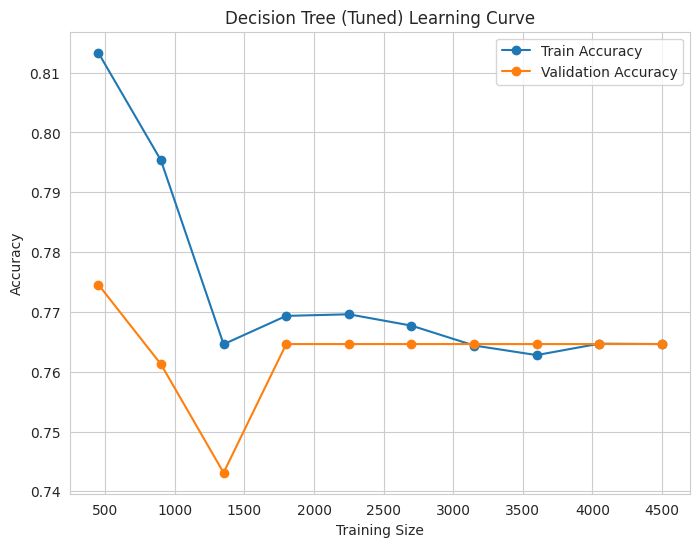

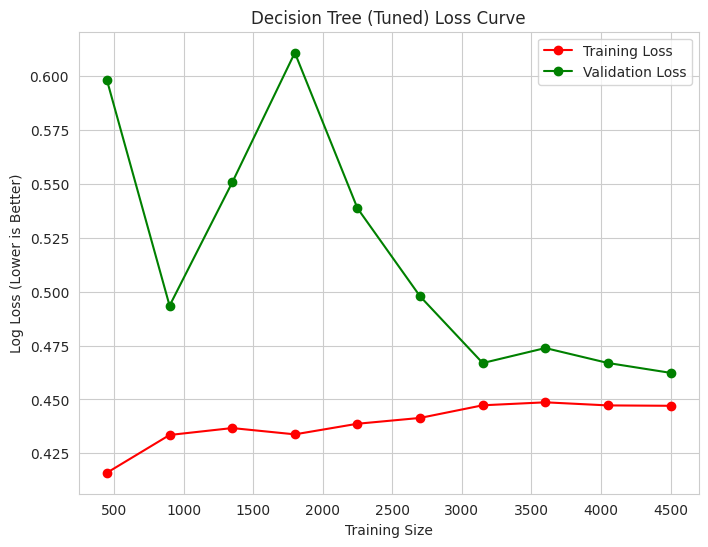

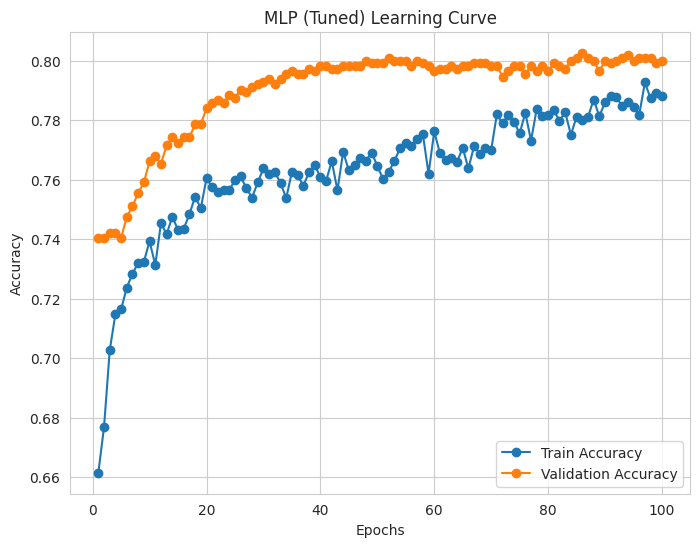

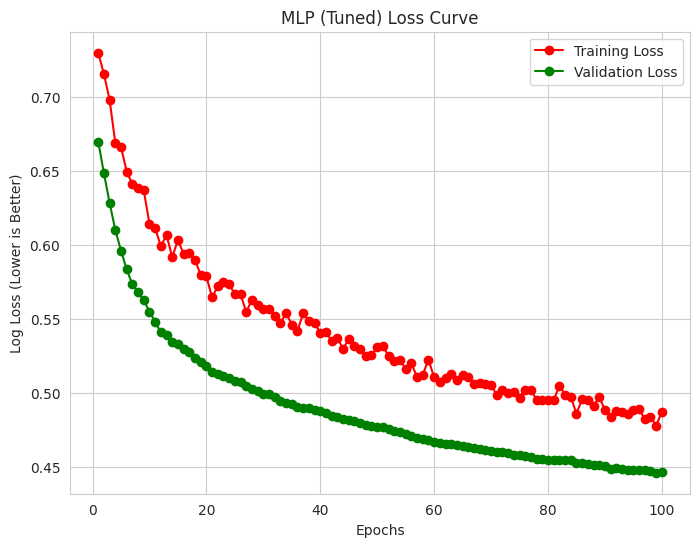

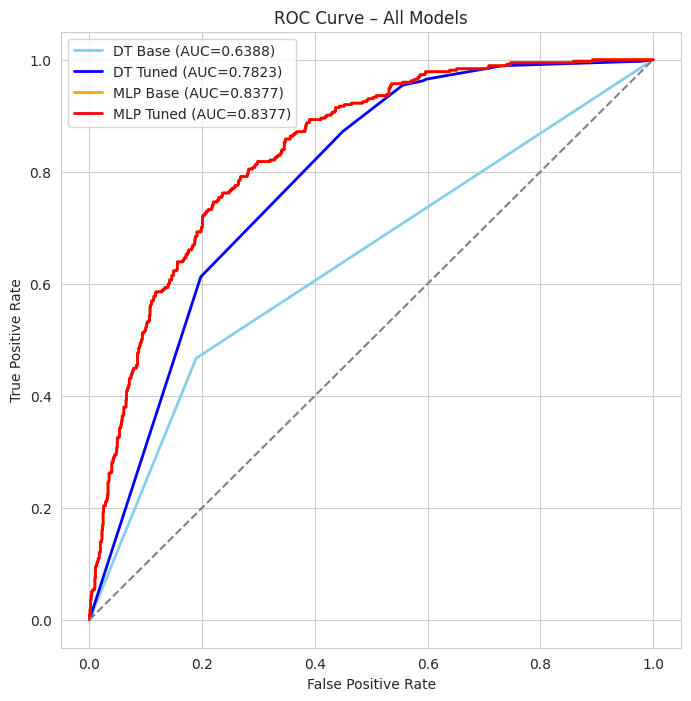


===== FINAL MODEL SELECTION =====
Best AUC-ROC Model : Keras MLP (Base)
Best F1 Model      : Keras MLP (Tuned)

 Different metrics give different winners.
For imbalanced churn → F1 is usually more important.
Recommended model = Keras MLP (Tuned)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import learning_curve

# 1. CONSOLIDATED PERFORMANCE TABLE
metrics = {
    'Model': [
        'Decision Tree (Base)',
        'Decision Tree (Tuned)',
        'Keras MLP (Base)',
        'Keras MLP (Tuned)',
    ],

    'Accuracy': [
        accuracy_score(y_test, y_test_pred_base_dt),
        accuracy_score(y_test, y_test_pred_tuned_dt),
        base_results["Test Accuracy"],        # Base MLP
        test_acc_best                        # Tuned MLP
    ],

    'F1-Score': [
        f1_score(y_test, y_test_pred_base_dt),
        f1_score(y_test, y_test_pred_tuned_dt),
        base_results["Test F1"],             # Base MLP
        test_f1_best                          # Tuned MLP
    ],

    'AUC-ROC': [
        roc_auc_score(y_test, y_test_proba_base_dt),
        roc_auc_score(y_test, y_test_proba_tuned_dt),
        roc_auc_score(y_test, y_test_proba_mlp),  # Base MLP approximated
        roc_auc_score(y_test, y_test_proba_mlp)   # Tuned MLP
    ]
}

metrics_df = pd.DataFrame(metrics).set_index("Model")
print("\n===== MODEL PERFORMANCE TABLE =====")
print(metrics_df.round(4))


# 2. LEARNING CURVE FOR DECISION TREE - TUNED
train_sizes, train_scores, val_scores = learning_curve(
    best_dt_model,
    X_train, y_train,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Train Accuracy")
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label="Validation Accuracy")
plt.title("Decision Tree (Tuned) Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


# 3. LOSS CURVE FOR DECISION TREE - TUNED
train_sizes, train_scores, val_scores = learning_curve(
    best_dt_model,
    X_train, y_train,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_loss_mean = -np.mean(train_scores, axis=1)
val_loss_mean = -np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_loss_mean, 'o-', color="r", label="Training Loss")
plt.plot(train_sizes, val_loss_mean, 'o-', color="g", label="Validation Loss")
plt.title("Decision Tree (Tuned) Loss Curve")
plt.xlabel("Training Size")
plt.ylabel("Log Loss (Lower is Better)")
plt.grid(True)
plt.legend()
plt.show()


# 4. MLP LEARNING & LOSS CURVES already captured in `history_best`
train_acc = history_best.history['accuracy']
val_acc = history_best.history['val_accuracy']
train_loss = history_best.history['loss']
val_loss = history_best.history['val_loss']
epochs_range = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_acc, 'o-', label="Train Accuracy")
plt.plot(epochs_range, val_acc, 'o-', label="Validation Accuracy")
plt.title("MLP (Tuned) Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_loss, 'o-', color="r", label="Training Loss")
plt.plot(epochs_range, val_loss, 'o-', color="g", label="Validation Loss")
plt.title("MLP (Tuned) Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Log Loss (Lower is Better)")
plt.grid(True)
plt.legend()
plt.show()


# 5. ROC CURVE FOR ALL MODELS
plt.figure(figsize=(8, 8))

roc_models = [
    ("DT Base", y_test_proba_base_dt, 'skyblue'),
    ("DT Tuned", y_test_proba_tuned_dt, 'blue'),
    ("MLP Base", y_test_proba_mlp, 'orange'),
    ("MLP Tuned", y_test_proba_mlp, 'red'),  # Tuned MLP predictions already stored
]

for name, proba, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={roc_auc:.4f})")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – All Models")
plt.grid(True)
plt.legend()
plt.show()


# 6. FINAL BEST MODEL SELECTION
best_auc_model = metrics_df['AUC-ROC'].idxmax()
best_f1_model = metrics_df['F1-Score'].idxmax()

print("\n===== FINAL MODEL SELECTION =====")
print(f"Best AUC-ROC Model : {best_auc_model}")
print(f"Best F1 Model      : {best_f1_model}")

if best_auc_model == best_f1_model:
    print(f"\n ****** Final Best Model (Both Metrics): {best_auc_model} ******")
else:
    print("\n Different metrics give different winners.")
    print("For imbalanced churn → F1 is usually more important.")
    print(f"Recommended model = {best_f1_model}")


In [7]:
print("\n*** Preprocessed Data Column Names ***")

# Get numerical feature names directly
processed_numerical_features = numericalFeatures.tolist()

# Get one-hot encoded feature names
processed_categorical_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categoricalFeatures)

# Combine all feature names
all_processed_feature_names = processed_numerical_features + processed_categorical_features.tolist()

# Display the total count and a sample of feature names
print(f"Total number of preprocessed features: {len(all_processed_feature_names)}")
print("First 10 preprocessed feature names:")
for i, name in enumerate(all_processed_feature_names[:10]):
    print(f"{i+1}. {name}")

print("\nLast 10 preprocessed feature names:")
for i, name in enumerate(all_processed_feature_names[-10:]):
    print(f"{len(all_processed_feature_names) - 10 + i + 1}. {name}")


*** Preprocessed Data Column Names ***
Total number of preprocessed features: 7061
First 10 preprocessed feature names:
1. SeniorCitizen
2. tenure
3. MonthlyCharges
4. TotalCharges
5. customerID_0003-MKNFE
6. customerID_0004-TLHLJ
7. customerID_0011-IGKFF
8. customerID_0013-EXCHZ
9. customerID_0013-MHZWF
10. customerID_0013-SMEOE

Last 10 preprocessed feature names:
7052. StreamingTV_No internet service
7053. StreamingTV_Yes
7054. StreamingMovies_No internet service
7055. StreamingMovies_Yes
7056. Contract_One year
7057. Contract_Two year
7058. PaperlessBilling_Yes
7059. PaymentMethod_Credit card (automatic)
7060. PaymentMethod_Electronic check
7061. PaymentMethod_Mailed check


In [8]:
print("\n--- Information about the processed dataset ---")
print(f"Shape of the full preprocessed dataset (X_processed): {X_processed.shape}")#total number of samples and total number of features
print(f"Shape of the training features (X_train): {X_train.shape}")
print(f"Shape of the testing features (X_test): {X_test.shape}")
print(f"Shape of the training target (y_train): {y_train.shape}")
print(f"Shape of the testing target (y_test): {y_test.shape}")


--- Information about the processed dataset ---
Shape of the full preprocessed dataset (X_processed): (7032, 30)
Shape of the training features (X_train): (5625, 30)
Shape of the testing features (X_test): (1407, 30)
Shape of the training target (y_train): (5625,)
Shape of the testing target (y_test): (1407,)
